<a href="https://colab.research.google.com/github/topherthib/IT480-FA26/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Hyperparameter Tuning and Fixing Overfitting Points

**Name:** Christopher Thibodeau, Mark Hanafin


## Setup — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))

        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")

        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(title)
        plt.legend()
        plt.show()

The original Wine Quality scores are imbalanced, particularly at the
extreme scores. As in Lab 1, the scores are grouped into three broader
quality classes:

- **Low (0):** quality ≤ 5
- **Medium (1):** quality = 6
- **High (2):** quality ≥ 7

In [3]:
wine = fetch_openml(
    name="wine-quality-red",
    version=1,
    as_frame=True,
    parser="auto"
)

df3 = wine.frame

print("Dataset shape:", df3.shape)
print("\nOriginal quality distribution:")
print(df3["class"].astype(int).value_counts().sort_index())

Dataset shape: (1599, 12)

Original quality distribution:
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [4]:
# Bucket raw quality scores into 3 bands: Low / Medium / High
#The resulting dataset contains three classes.

#The Low and Medium classes
#are relatively similar in size, while the High class contains substantially
#fewer examples.

def bucket_quality(q):
    q = int(q)

    if q <= 5:
        return 0  # Low
    elif q == 6:
        return 1  # Medium
    else:
        return 2  # High


df3["quality_band"] = df3["class"].apply(bucket_quality)

print("Class distribution:")
print(df3["quality_band"].value_counts().sort_index())

Class distribution:
quality_band
0    744
1    638
2    217
Name: count, dtype: int64


In [5]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

x3_scaler = StandardScaler()

X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

print("Training samples:", X3_train_scaled.shape[0])
print("Testing samples:", X3_test_scaled.shape[0])
print("Number of features:", X3_train_scaled.shape[1])

Training samples: 1279
Testing samples: 320
Number of features: 11


In [6]:
#The following model is the original multiclass MLP used in Lab 1.
#It contains two hidden layers with 128 and 32 neurons using ReLU
#activation. The output layer contains one neuron for each of the three
#classes and uses softmax activation.

n_classes = len(np.unique(y3))

model_multi = tf.keras.Sequential([
    tf.keras.layers.Dense(
        128,
        activation="relu",
        input_shape=(X3_train_scaled.shape[1],)
    ),

    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        n_classes,
        activation="softmax"
    )
])

model_multi.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_multi.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,763 (22.51 KB)

 Trainable params: 5,763 (22.51 KB)

 Non-trainable params: 0 (0.00 B)

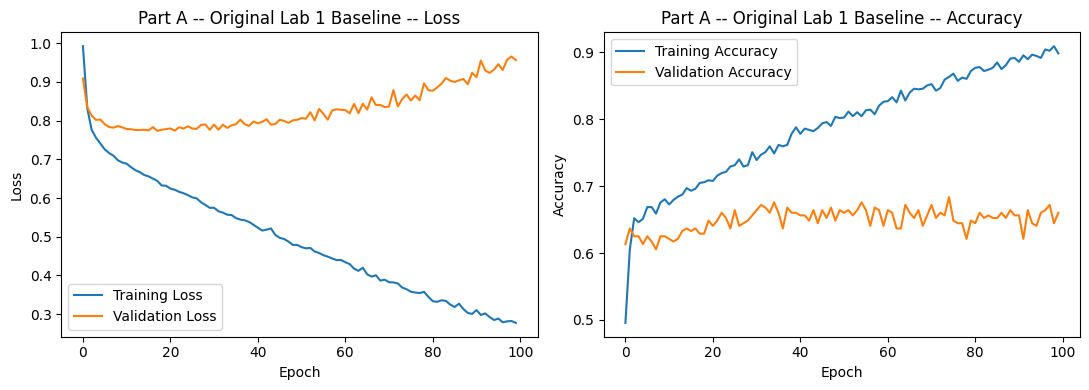

In [7]:
#The baseline model is trained using the same settings as Lab 1: 100
#epochs, a batch size of 32, and 20% of the training data reserved for
#validation.

history_multi = model_multi.fit(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(
    history_multi,
    "Part A -- Original Lab 1 Baseline",
    show_accuracy=True
)

### Baseline Overfitting Analysis

The original Lab 1 model shows evidence of **overfitting**. Early in
training, the training and validation loss decrease together. As training
continues, however, the training loss continues to decrease while the
validation loss begins to increase substantially.

The growing gap between training and validation loss indicates that the
model is continuing to improve its fit to the training data without
improving its ability to generalize to unseen validation data.

### Test Performance

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Baseline Test Accuracy: 0.688


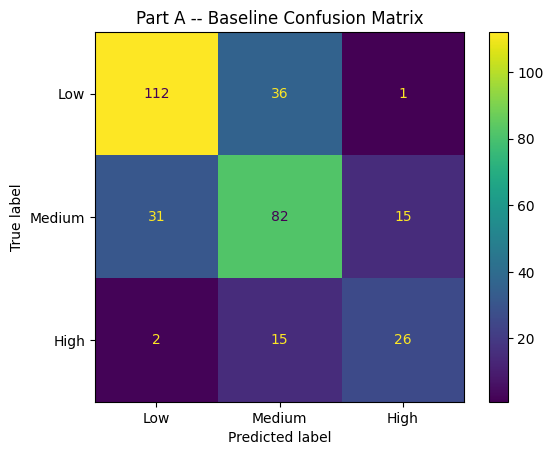

In [8]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)

print(f"Baseline Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)

ConfusionMatrixDisplay(
    cm3,
    display_labels=["Low", "Medium", "High"]
).plot()

plt.title("Part A -- Baseline Confusion Matrix")
plt.show()

### Baseline Results

The original Lab 1 run achieved a test accuracy of **66.2%**.

The confusion matrix showed that the model most frequently confused the
**Low and Medium** classes. Medium and High wines were also confused, but
less frequently. This is reasonable because the classes were created by
grouping neighboring numerical wine-quality scores into broader categories.

Overall, the baseline model achieved reasonable classification accuracy,
but the training and validation loss curves showed that the model was
overfitting as training continued.

# Part B — Hyperparameter Tuning

In [9]:
!pip install keras-tuner --quiet
import keras_tuner as kt

n_features = X3_train_scaled.shape[1]
n_classes = 3

def build_model(hp):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            hp.Int("hidden1", min_value=16, max_value=128, step=16),
            activation="relu",
            input_shape=(n_features,)
        ),

        tf.keras.layers.Dense(
            hp.Int("hidden2", min_value=8, max_value=64, step=8),
            activation="relu"
        ),

        tf.keras.layers.Dense(
            n_classes,
            activation="softmax"
        )
    ])

    learning_rate = hp.Choice(
        "learning_rate",
        values=[0.0001, 0.001, 0.01]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.1 MB/s eta 0:00:00


In [10]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=10,
    overwrite=True,
    directory="tuning",
    project_name="wine_quality"
)

tuner.search(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=50,
    verbose=1
)

Trial 10 Complete [00h 00m 13s]
val_loss: 0.8950698971748352

Best val_loss So Far: 0.7535837888717651
Total elapsed time: 00h 02m 50s


In [11]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters:")
print("Hidden layer 1:", best_hp.get("hidden1"))
print("Hidden layer 2:", best_hp.get("hidden2"))
print("Learning rate:", best_hp.get("learning_rate"))

Best hyperparameters:
Hidden layer 1: 64
Hidden layer 2: 16
Learning rate: 0.01


In [12]:
tuned_model = tuner.hypermodel.build(best_hp)

history_tuned = tuned_model.fit(
    X3_train_scaled,
    y3_train,
    validation_split=0.2,
    epochs=50,
    verbose=0
)

test_loss, test_accuracy = tuned_model.evaluate(
    X3_test_scaled,
    y3_test,
    verbose=0
)

print(f"Tuned Test Accuracy: {test_accuracy:.3f}")

Tuned Test Accuracy: 0.672


### Confirming Changes in Accuracy

In [13]:
improvement = test_accuracy - acc_multi

print(f"Baseline Accuracy: {acc_multi:.3f}")
print(f"Tuned Accuracy:    {test_accuracy:.3f}")
print(f"Change:            {improvement:+.3f}")

Baseline Accuracy: 0.688
Tuned Accuracy:    0.672
Change:            -0.016
